Most of the stuff here is focused on comparing the output a preliminary time slicing algorithm with merged and unmerged hits. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import collections

In [3]:
#We can pull in our merged and unmerged hit data. The neutrino vertices array is common to both files.
data_unmerged = np.load('../hitwise_detector_sim_0002459.npz')
data_merged = np.load('../python/test_0002459_merged.npz')
neutrino_vertices = data_unmerged['first']
hit_array_unmerged = data_unmerged['second']
hit_array_merged = data_merged['first']
print(np.shape(hit_array_unmerged))
print(np.shape(hit_array_merged))

(252256, 7)
(107479, 8)


In [4]:
#Some useful sorting functions
def SortByTime(array):
    sorted_array = array[np.argsort(array[:,5])]
    return(sorted_array)

def SortByNN(array):
    sorted_array = array[np.argsort(array[:,0])]
    return(sorted_array)

In [5]:
sorted_hits_merged = SortByTime(hit_array_merged)
sorted_hits_unmerged = SortByTime(hit_array_unmerged)

In [6]:
#A useful data structure that can serve as a test of energy efficiency

#Creates this array using unmerged PEs
neutrino_PE_array_unmerged = np.zeros((5979, 3))
for i in range(5979):
    PEs = 0.
    sub_array = sorted_hits_unmerged[sorted_hits_unmerged[:, 0] == i]
    n_hits = 0
    if np.shape(sub_array)[0] > 0:
        for hit in sub_array:
            n_hits += 1 
            PEs += hit[6]
    neutrino_PE_array_unmerged[i][0] = i
    neutrino_PE_array_unmerged[i][1] = PEs
    neutrino_PE_array_unmerged[i][2] = n_hits

print(neutrino_PE_array_unmerged)

#Creates this array using unmerged PEs
neutrino_PE_array_merged = np.zeros((5979, 3))
for i in range(5979):
    PEs = 0.
    sub_array = sorted_hits_merged[sorted_hits_merged[:, 0] == i]
    n_hits = 0
    if np.shape(sub_array)[0] > 0:
        for hit in sub_array:
            n_hits += 1
            PEs += hit[6]
    neutrino_PE_array_merged[i][0] = i
    neutrino_PE_array_merged[i][1] = PEs
    neutrino_PE_array_merged[i][2] = n_hits

print(neutrino_PE_array_merged)




[[0.00000000e+00 7.34770243e+01 5.00000000e+00]
 [1.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.00000000e+00 1.28117544e+03 8.30000000e+01]
 ...
 [5.97600000e+03 0.00000000e+00 0.00000000e+00]
 [5.97700000e+03 3.66649168e+03 1.65000000e+02]
 [5.97800000e+03 0.00000000e+00 0.00000000e+00]]
[[0.00000000e+00 7.34770243e+01 2.00000000e+00]
 [1.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.00000000e+00 1.28117544e+03 5.10000000e+01]
 ...
 [5.97600000e+03 0.00000000e+00 0.00000000e+00]
 [5.97700000e+03 3.66649168e+03 5.40000000e+01]
 [5.97800000e+03 0.00000000e+00 0.00000000e+00]]


In [7]:
#As a quick check, the sum of PEs for these should be the same - good they are!
print(np.sum(neutrino_PE_array_merged[:,1]))
print(np.sum(neutrino_PE_array_unmerged[:,1]))

4580167.087710667
4580167.087710667


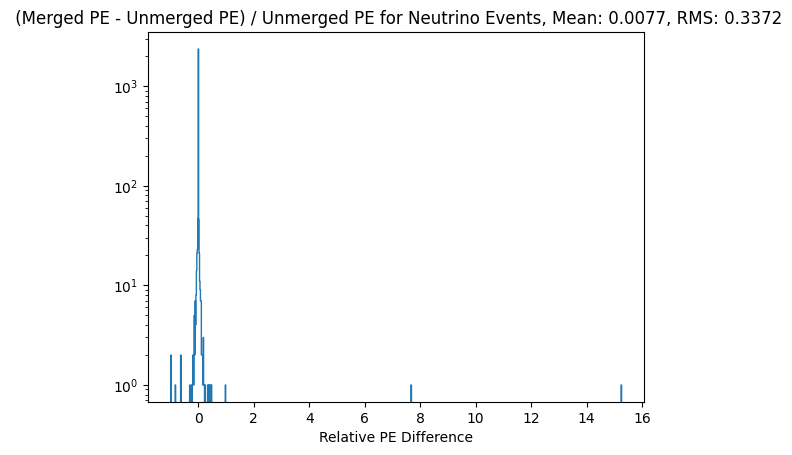

In [7]:
rel_PE_differences = [] #merged - unmerged
for i in range(5979): 
    merged_PE = neutrino_PE_array_merged[i][1]
    unmerged_PE = neutrino_PE_array_unmerged[i][1]
    if unmerged_PE != 0:
        rel_diff = (merged_PE - unmerged_PE) / unmerged_PE
        rel_PE_differences.append(rel_diff)
avg = np.mean(rel_PE_differences)
rms = np.sqrt(np.mean(np.array(rel_PE_differences)**2))
plt.hist(rel_PE_differences, bins = 1000, histtype = 'step')
plt.yscale('log')
#plt.xlim((-1.5,1.5))
plt.title(f' (Merged PE - Unmerged PE) / Unmerged PE for Neutrino Events, Mean: {avg:.4f}, RMS: {rms:.4f}')
plt.xlabel("Relative PE Difference")
plt.show()

2627
704
2
571.0
[np.float64(729.0), np.float64(1222.0)]


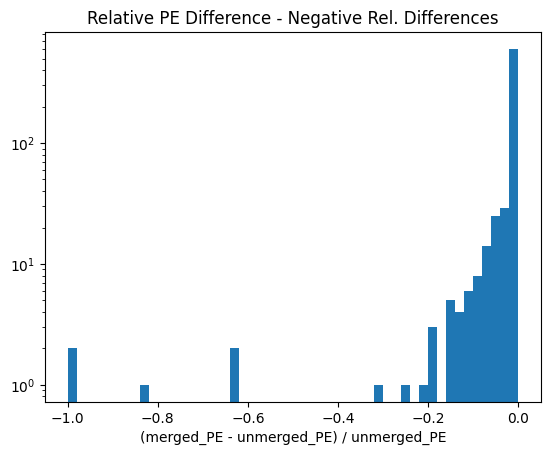

In [8]:
non_zero_unmerged_PE = [] #stores the total PE for non-zero merged events.
reldeltaPE_list = []
negative_deltas = []
removed_vtx = []
loss_20 = 0.
for i in range(5979):
    merged_PE = neutrino_PE_array_merged[i][1]
    unmerged_PE = neutrino_PE_array_unmerged[i][1]
    if unmerged_PE != 0: #if we have non-zero PE for this neutrino
        non_zero_unmerged_PE.append(unmerged_PE)
        reldeltaPE = (merged_PE - unmerged_PE) / unmerged_PE #if negative, our neutrino event has lost energy as a result of merging. 
        reldeltaPE_list.append(reldeltaPE)
        if reldeltaPE < 0:
            negative_deltas.append(reldeltaPE)
            if reldeltaPE <= -1:
                removed_vtx.append(neutrino_PE_array_unmerged[i][0])
            if reldeltaPE >= -0.01:
                loss_20 += 1
                

print(len(non_zero_unmerged_PE))
print(len(negative_deltas))
print(len(removed_vtx))
print(loss_20)
print(removed_vtx)

plt.hist(negative_deltas, bins = 50)
plt.yscale('log')
plt.title("Relative PE Difference - Negative Rel. Differences")
plt.xlabel("(merged_PE - unmerged_PE) / unmerged_PE")
plt.show()
        

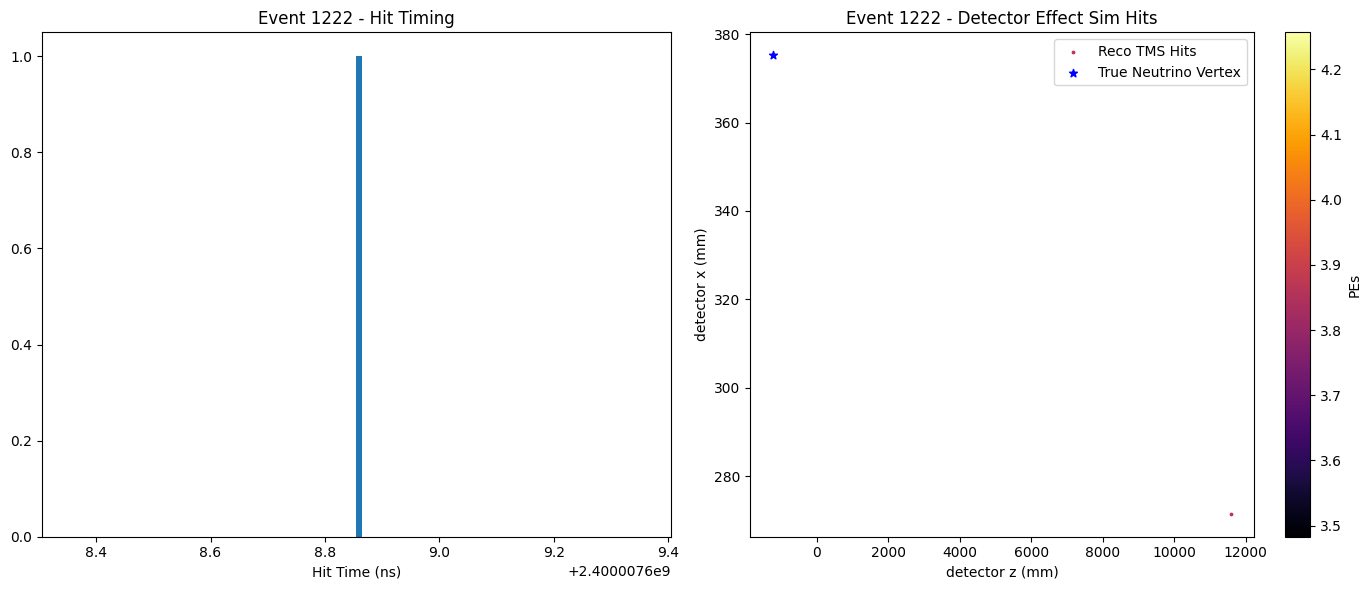

In [9]:
#Quick event display to take a look at these events which get lost
event_number_example = 1222

# Reco hit data
reco_hit_xs = []
reco_hit_zs = []
reco_hit_PEs = []
reco_hit_Ts = []

for hit in hit_array_unmerged:
    if (hit[0] == event_number_example):
        reco_hit_xs.append(hit[2])
        reco_hit_zs.append(hit[4])
        reco_hit_Ts.append(hit[5])
        reco_hit_PEs.append(hit[6])

event_neutrino = [vtx for vtx in neutrino_vertices if vtx[0] == event_number_example]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot reco hits
sc2 = ax2.scatter(reco_hit_zs, reco_hit_xs, s=3, c=reco_hit_PEs, cmap='inferno', label='Reco TMS Hits')
ax2.scatter(event_neutrino[0][3], event_neutrino[0][1], s=35, c='blue', marker='*', label='True Neutrino Vertex')
ax2.set_xlabel("detector z (mm)")
ax2.set_ylabel("detector x (mm)")
ax2.set_title(f"Event {event_number_example} - Detector Effect Sim Hits")
ax2.legend()
fig.colorbar(sc2, ax=ax2, label='PEs')

# Plot truth hits
sc1 = ax1.hist(reco_hit_Ts, bins=100)
ax1.set_xlabel("Hit Time (ns)")
ax1.set_title(f"Event {event_number_example} - Hit Timing")

plt.tight_layout()
plt.show()


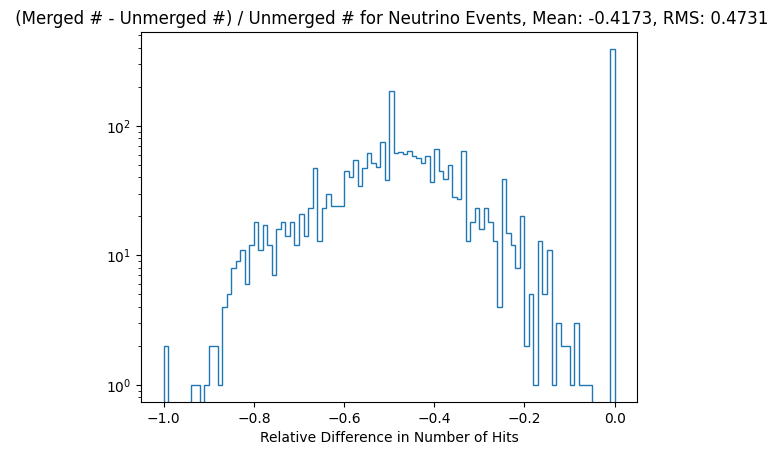

In [10]:
rel_hitnum_differences = [] #merged - unmerged
for i in range(5979): 
    merged_hitsn = neutrino_PE_array_merged[i][2]
    unmerged_hitsn = neutrino_PE_array_unmerged[i][2]
    if unmerged_hitsn != 0:
        rel_diff = (merged_hitsn - unmerged_hitsn) / unmerged_hitsn
        rel_hitnum_differences.append(rel_diff)
avg = np.mean(rel_hitnum_differences)
rms = np.sqrt(np.mean(np.array(rel_hitnum_differences)**2))
plt.hist(rel_hitnum_differences, bins = 100, histtype = 'step')
plt.yscale('log')
#plt.xlim((-1.5,1.5))
plt.title(f' (Merged # - Unmerged #) / Unmerged # for Neutrino Events, Mean: {avg:.4f}, RMS: {rms:.4f}')
plt.xlabel("Relative Difference in Number of Hits")
plt.show()

In [70]:
#A time slicer based on the principles of the dune-tms slicer. takes thresholds and a hits array. I think this is working as intended. 
#This function will return a list of lists of arrays. lol
#Patched to stop adding the hit after energy drops below threshold

def SimpleTimeSlicer(hits, initial_threshold_energy=50, drop_threshold_energy=40):
    sorted_hits = SortByTime(hits)
    events = []  # This object stores the final "events" or slices that are grouped by the algorithm
    window_duration_ns = 19

    current_window_hits = collections.deque()
    current_window_energy_sum = 0.0

    in_accumulation_phase = False
    current_event_hits = []  # Stores hit info for our event that is accumulating

    for hit_row in sorted_hits:  # Iterate through each full hit row
        hit_time = hit_row[5]    # Time is at index 5
        hit_energy = hit_row[6]  # Energy is at index 6

        # Add the current full hit row to the window
        current_window_hits.append(hit_row)  # Store the entire row
        current_window_energy_sum += hit_energy  # Add the hit energy to our current window

        # Remove hits that are outside the current window, basically sliding the deque forward
        # The window is defined by (current_hit_time - window_duration_ns, current_hit_time]
        while current_window_hits and current_window_hits[0][5] <= hit_time - window_duration_ns:
            # This loop removes all hits from the front of the window that are outside 
            # the time range (older than hit_time - window_duration_ns)
            oldest_hit_row = current_window_hits.popleft()  # Get the full oldest row
            oldest_hit_energy = oldest_hit_row[6]  # Access energy from the row
            current_window_energy_sum -= oldest_hit_energy

        # Handle accumulation logic
        if not in_accumulation_phase:
            # Not in accumulation, if we pass the threshold we should start
            if current_window_energy_sum >= initial_threshold_energy:
                in_accumulation_phase = True  # Here we activate accumulation mode - begin a slice.
                # When we *start* accumulation, initialize `current_event_hits` with
                # all hits currently within the *valid* window (i.e., those in `current_window_hits`).
                # We need to make a copy here (`list(...)`) because `current_window_hits`
                # will continue to change as the window slides.
                # This making a copy rather than grabbing it every time the hit slides 
                # was the reason we encountered duplicates in previous versions
                current_event_hits = list(current_window_hits)
        else:
            # We ARE currently in an accumulation phase
            # Check if the energy in the *current window* has dropped below the threshold,
            # BEFORE adding the most recent hit to the accumulating event
            if current_window_energy_sum < drop_threshold_energy:
                # If indeed we have dropped below threshold, go ahead and 
                events.append(current_event_hits)
                in_accumulation_phase = False  # Turning off accumulation mode
                current_event_hits = []  # Reset for the next event - dumping the current event's hit list
            else:
                # Still above threshold, so include the current hit
                current_event_hits.append(hit_row)

    # After iterating through all hits, check if we were still in an accumulation phase.
    # If so, the last event needs to be saved, it won't do this automatically!
    if in_accumulation_phase:
        events.append(current_event_hits)

    return events


In [71]:
#Some other utility functions

#this function checks how many total events were placed into groups. 
def ValidateEvents(events, hit_array_merged):
    hits_sliced = 0
    for group in events:
        for hit in group:
            hits_sliced += 1
    missing = (np.shape(hit_array_merged)[0] - hits_sliced)
    missing_ratio = missing / np.shape(hit_array_merged)[0]
    print(f"Grouped {hits_sliced} hits into {len(events)} slices, {missing} hits were not grouped, {(missing_ratio * 100):2f}% of total")
    return(hits_sliced, missing, missing_ratio)

#this function will return a list of hits grouped into arrays based on their event. May incorporate into main function...
#then individual slices can be accessed by their index. 
def StackEvents(events):
    event_list = []
    for i in range(len(events)):
        event_list.append(np.vstack(events[i]))
    return(event_list)
            
#This function can print out the time slices
def SlicerPrinting(events, loud = False):
    print(f"Detected {len(events)} slices:")
    for i, event in enumerate(events):
        print(f"\n--- Event {i+1} ---")
        total_energy_event = sum(hit_row[6] for hit_row in event) # Sum energy from full rows
        print(f"Total hits: {len(event)}")
        print(f"Total energy: {total_energy_event:.2f}")
        # Get min/max time from the full hit rows in the event
        if event: # Ensure event is not empty before accessing elements
            start_time = min(hit_row[5] for hit_row in event)
            end_time = max(hit_row[5] for hit_row in event)
            print(f"Time range: {start_time:.1f} ns - {end_time:.1f} ns")
            print(f"Total time: {(end_time - start_time):.2f} ns")
            
        if loud:
            print("Hits (full data) in event:")
            for hit_row in event:
                # Print specific fields for clarity, or the whole row
                print(f"  Neutrino: {hit_row[0]}, Hit: {hit_row[1]}, Time: {hit_row[5]:.1f}, Energy: {hit_row[6]:.1f}, X: {hit_row[2]}")

def TimePlot(events, slices_to_grab, init_thresh, drop_thresh):
    slice_stack = StackEvents(events)
    slices_grabbed = slice_stack[:slices_to_grab]
    for time_slice in slices_grabbed:
        plt.hist(time_slice[:,5])

    plt.title(f"First {slices_to_grab} Slices - Init Thresh {init_thresh} PE, Drop Thresh {drop_thresh} PE ")
    plt.xlabel("Hit Time (ns)")
    plt.ylabel("# hits")
    plt.show()

In [67]:
init_thresh = 50
drop_thresh = 60
sliced = SimpleTimeSlicer(hit_array_merged, initial_threshold_energy = init_thresh, drop_threshold_energy = drop_thresh) #15, 7
put_in_slices, no_in_slices, frac_not_in_slices = ValidateEvents(sliced, hit_array_merged)

Grouped 105373 hits into 1420 slices, 2106 hits were not grouped, 1.959453% of total


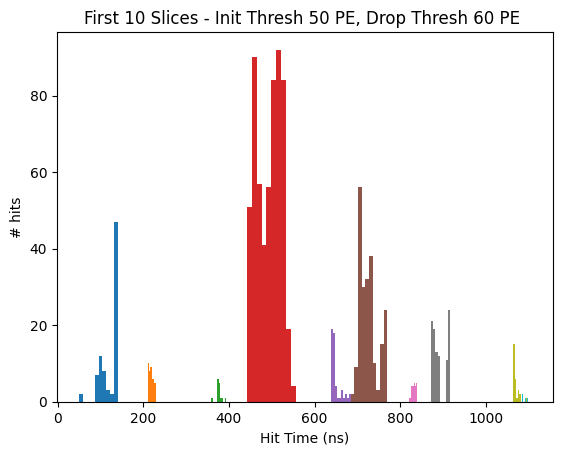

In [72]:
TimePlot(sliced, 10, init_thresh, drop_thresh)

In [73]:
slice_stack = StackEvents(sliced)

In [74]:
#An actual efficiency and purity metric maker for our time slicer. 


#we will be referencing this array: neutrino_PE_array_merged , at end will have to rememeber to only care about events with non-zero merged PE. 
#neutrino_PE_array_merged

#the containment array object evaluates how well our time slicing does! 

containment_array = np.zeros((5979,5)) #|nn | hit containment | PE containment | best hit containment slice | best PE containment slice |
purity_array = np.zeros((len(slice_stack),2))

for i in range(5978):
    containment_array[i][0] = i

for j in range(len(slice_stack)):
    slice_number = j
    selected_slice = slice_stack[j]
    nns = selected_slice[:,0] #grab the neutrino numbers
    nns_represented, counts = np.unique(nns, return_counts = True) #counts can be used to determine the hit containment, need to loop for PEs
    purity_array[slice_number][0] = slice_number
    purity_array[slice_number][1] = len(nns_represented) #fill our purity array with number of 
    for i, nn in enumerate(nns_represented):
        total_hits = neutrino_PE_array_merged[int(nn)][2] #total hits
        total_PEs = neutrino_PE_array_merged[int(nn)][1] #total PE
        hits_in_slice = counts[i] #hits in this slice
        filtered_rows = (slice_stack[slice_number][slice_stack[slice_number][:, 0] == nn]) #grab subarray of rows with our hits
        PEs_in_slice = np.sum(filtered_rows[:,6]) #sum all the PEs for this nn in the slice. 
        
        containment_array[int(nn)][0] = nn #neutrino_number
        
        if (containment_array[int(nn)][1]) <= (hits_in_slice / total_hits) :
            containment_array[int(nn)][1] = hits_in_slice / total_hits #hits contained
            containment_array[int(nn)][3] = slice_number

        if (containment_array[int(nn)][2]) <= (PEs_in_slice / total_PEs) :
            containment_array[int(nn)][2] = PEs_in_slice / total_PEs #PEs contained
            containment_array[int(nn)][4] = slice_number #this slice. 
      


In [78]:
neutrinos_with_TMS_hits = np.where(neutrino_PE_array_merged[:, 2] != 0)[0] #grab indexes of the neutrino vertex array with TMS activity
print(neutrinos_with_TMS_hits)
len(neutrinos_with_TMS_hits)

[   0    2    3 ... 5974 5975 5977]


2625

In [36]:
print(containment_array)

[[0.00000000e+00 1.00000000e+00 1.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [2.00000000e+00 9.60784314e-01 9.94293499e-01 0.00000000e+00
  0.00000000e+00]
 ...
 [5.97600000e+03 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [5.97700000e+03 9.81481481e-01 9.99147312e-01 1.18300000e+03
  1.18300000e+03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]]


In [37]:
relevant_containment_array = containment_array[neutrinos_with_TMS_hits]

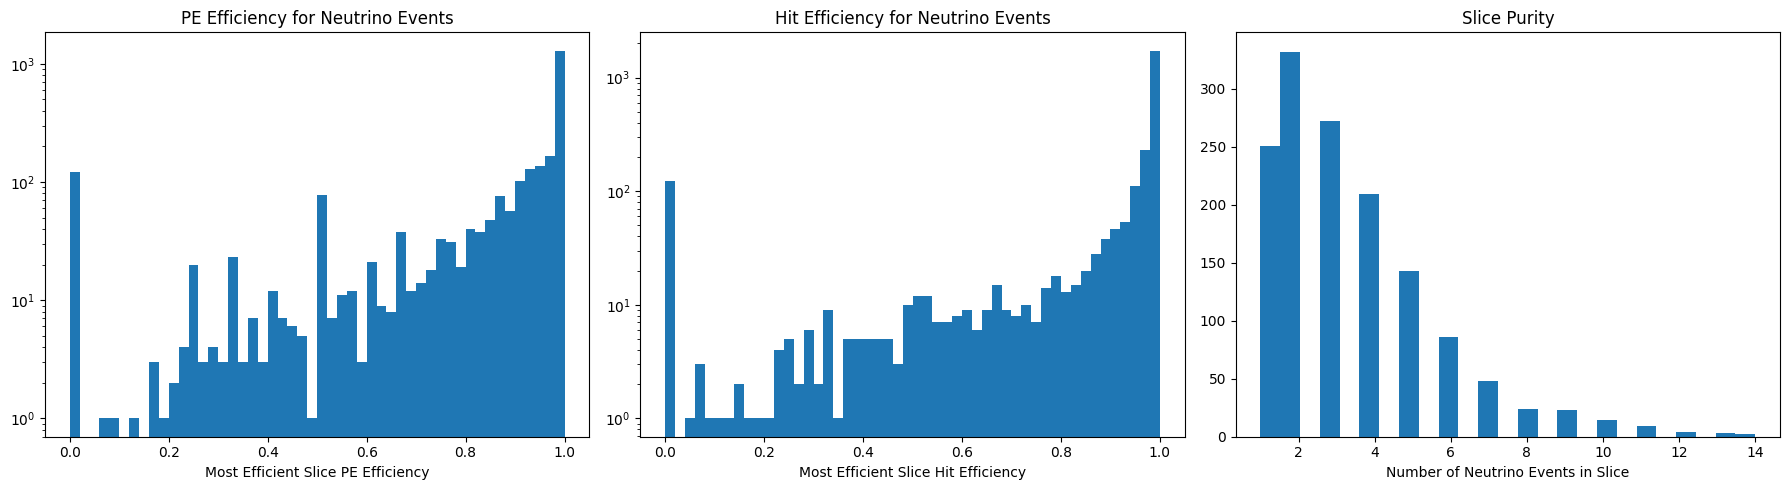

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: PE Efficiency
axes[0].hist(relevant_containment_array[:,1], bins=50)
axes[0].set_title("PE Efficiency for Neutrino Events")
axes[0].set_xlabel("Most Efficient Slice PE Efficiency")
axes[0].set_yscale('log')

# Plot 2: Hit Efficiency
axes[1].hist(relevant_containment_array[:,2], bins=50)
axes[1].set_title("Hit Efficiency for Neutrino Events")
axes[1].set_xlabel("Most Efficient Slice Hit Efficiency")
axes[1].set_yscale('log')

# Plot 3: Slice Purity
axes[2].hist(purity_array[:,1], bins=25)
axes[2].set_title("Slice Purity")
axes[2].set_xlabel("Number of Neutrino Events in Slice")

plt.tight_layout()
plt.show()